In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/phishing_email.csv")
df.shape

(82486, 2)

In [2]:
df.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [3]:
df.columns.tolist()

['text_combined', 'label']

In [4]:
df.iloc[:, -1].value_counts()

label
1    42891
0    39595
Name: count, dtype: int64

In [6]:
ceas = pd.read_csv("../data/raw/CEAS_08.csv")
ceas.shape

(39154, 7)

In [7]:
ceas.columns.tolist()

['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

In [8]:
ceas.head(3)

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1


In [9]:
import pandas as pd

files = ["Enron.csv", "Ling.csv", "Nazario.csv", "Nigerian_Fraud.csv", "SpamAssasin.csv"]
for f in files:
    d = pd.read_csv(f"../data/raw/{f}")
    print(f, "->", d.shape, "->", d.columns.tolist())

Enron.csv -> (29767, 3) -> ['subject', 'body', 'label']
Ling.csv -> (2859, 3) -> ['subject', 'body', 'label']
Nazario.csv -> (1565, 7) -> ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']
Nigerian_Fraud.csv -> (3332, 7) -> ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']
SpamAssasin.csv -> (5809, 7) -> ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']


In [10]:
files = {
    "CEAS_08.csv": "ceas",
    "Enron.csv": "enron",
    "Ling.csv": "ling",
    "Nazario.csv": "nazario",
    "Nigerian_Fraud.csv": "nigerian_fraud",
    "SpamAssasin.csv": "spamassasin"
}

for fname, label_name in files.items():
    d = pd.read_csv(f"../data/raw/{fname}")
    print(fname, "->", d["label"].value_counts().to_dict())

CEAS_08.csv -> {1: 21842, 0: 17312}
Enron.csv -> {0: 15791, 1: 13976}
Ling.csv -> {0: 2401, 1: 458}
Nazario.csv -> {1: 1565}
Nigerian_Fraud.csv -> {1: 3332}
SpamAssasin.csv -> {0: 4091, 1: 1718}


In [11]:
import pandas as pd

files = ["CEAS_08.csv", "Enron.csv", "Ling.csv", "Nazario.csv", "Nigerian_Fraud.csv", "SpamAssasin.csv"]

dfs = []
for f in files:
    d = pd.read_csv(f"../data/raw/{f}")
    d["source_file"] = f.replace(".csv", "")
    dfs.append(d)

combined = pd.concat(dfs, ignore_index=True)
combined.shape

(82486, 8)

In [12]:
combined["subject"] = combined["subject"].fillna("")
combined["body"] = combined["body"].fillna("")
combined["text"] = combined["subject"] + " " + combined["body"]
combined[["text", "label", "source_file"]].head()

,text,label,source_file
0,"Never agree to be a loser Buck up, your troubl...",1,CEAS_08
1,Befriend Jenna Jameson \nUpgrade your sex and ...,1,CEAS_08
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,1,CEAS_08
3,Re: svn commit: r619753 - in /spamassassin/tru...,0,CEAS_08
4,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,1,CEAS_08


In [13]:
combined["label"].value_counts()

label
1    42891
0    39595
Name: count, dtype: int64

In [ ]:
combined["source_file"].value_counts()

source_file
CEAS_08           39154
Enron             29767
SpamAssasin        5809
Nigerian_Fraud     3332
Ling               2859
Nazario            1565
Name: count, dtype: int64

In [15]:
combined["text"].duplicated().sum()

np.int64(0)

In [16]:
combined[combined["text"].duplicated(keep=False)].sort_values("text").head(10)

,sender,receiver,date,subject,body,label,urls,source_file,text


In [17]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\manvi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [18]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' URL ', text)      # normalize URLs to a token instead of deleting
    text = re.sub(r'\S+@\S+', ' EMAIL ', text)               # normalize email addresses
    text = re.sub(r'[^a-z\s]', ' ', text)                     # strip numbers/punctuation/symbols
    text = re.sub(r'\s+', ' ', text).strip()                  # collapse whitespace
    tokens = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

combined['clean_text'] = combined['text'].apply(clean_text)
combined[['text', 'clean_text']].head()

,text,clean_text
0,"Never agree to be a loser Buck up, your troubl...",never agree loser buck troubles caused small d...
1,Befriend Jenna Jameson \nUpgrade your sex and ...,befriend jenna jameson upgrade sex pleasures t...
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,cnn com daily top daily top cnn com top videos...
3,Re: svn commit: r619753 - in /spamassassin/tru...,svn commit spamassassin trunk lib mail spamass...
4,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,specialpricespharmmoreinfo welcomefastshipping...


In [19]:
combined['clean_text'].str.split().apply(len).describe()

count     82486.000000
mean        140.673617
std        1493.441669
min           0.000000
25%          28.000000
50%          64.000000
75%         158.000000
max      417687.000000
Name: clean_text, dtype: float64

In [22]:
before = len(combined)
combined = combined[combined['clean_text'].str.strip() != ''].reset_index(drop=True)
after = len(combined)
print(f"Dropped {before - after} rows with empty cleaned text")

Dropped 0 rows with empty cleaned text


In [23]:
combined.to_csv('../data/processed/emails_clean.csv', index=False)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    combined['clean_text'], combined['label'],
    test_size=0.2, random_state=42, stratify=combined['label']
)
X_train.shape, X_test.shape

((65939,), (16485,))

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000)),
    ('clf', MultinomialNB())
])
nb_pipeline.fit(X_train, y_train)
nb_preds = nb_pipeline.predict(X_test)
print(classification_report(y_test, nb_preds))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      7919
           1       0.98      0.95      0.96      8566

    accuracy                           0.96     16485
   macro avg       0.96      0.96      0.96     16485
weighted avg       0.96      0.96      0.96     16485



In [26]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000)),
    ('clf', LogisticRegression(max_iter=1000))
])
lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)
print(classification_report(y_test, lr_preds))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7919
           1       0.98      0.99      0.98      8566

    accuracy                           0.98     16485
   macro avg       0.98      0.98      0.98     16485
weighted avg       0.98      0.98      0.98     16485



In [27]:
print("Naive Bayes:\n", confusion_matrix(y_test, nb_preds))
print("Logistic Regression:\n", confusion_matrix(y_test, lr_preds))

Naive Bayes:
 [[7732  187]
 [ 424 8142]]
Logistic Regression:
 [[7744  175]
 [ 109 8457]]


In [28]:
import joblib

joblib.dump(nb_pipeline, '../src/naive_bayes_model.pkl')
joblib.dump(lr_pipeline, '../src/logistic_regression_model.pkl')

['../src/logistic_regression_model.pkl']

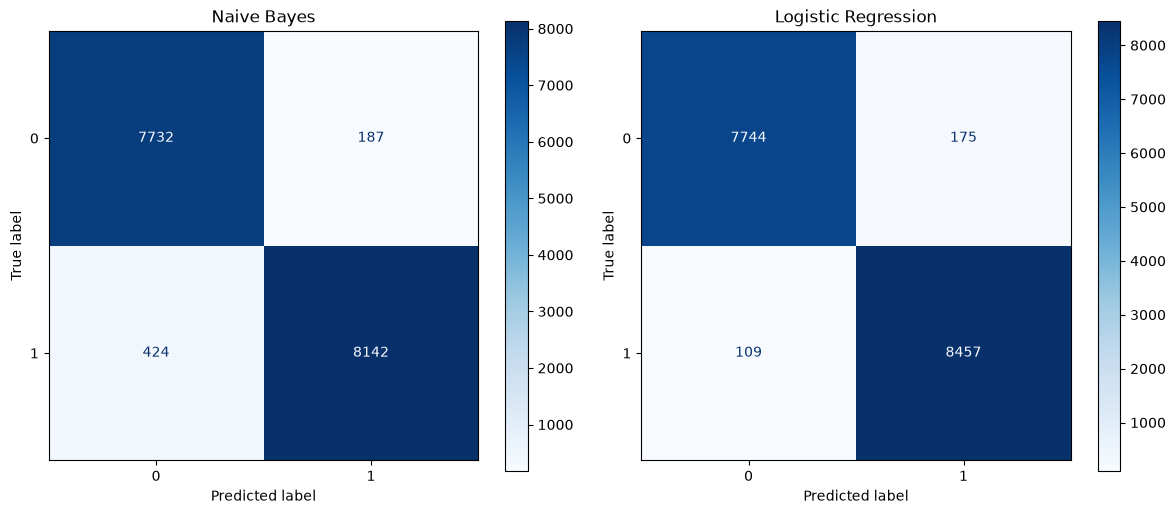

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, nb_preds, ax=axes[0], cmap='Blues')
axes[0].set_title('Naive Bayes')
ConfusionMatrixDisplay.from_predictions(y_test, lr_preds, ax=axes[1], cmap='Blues')
axes[1].set_title('Logistic Regression')
plt.tight_layout()
plt.savefig('../visuals/confusion_matrices.png', dpi=150)
plt.show()

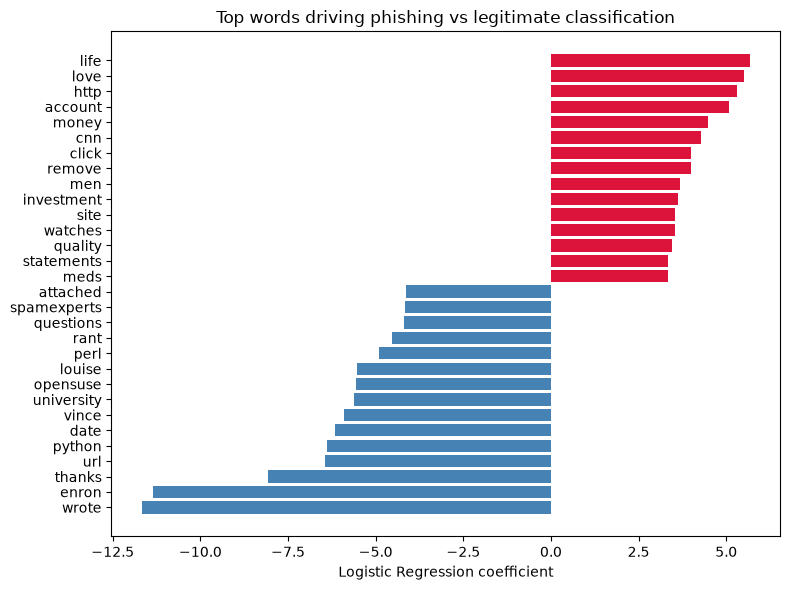

In [30]:
import numpy as np

feature_names = lr_pipeline.named_steps['tfidf'].get_feature_names_out()
coefs = lr_pipeline.named_steps['clf'].coef_[0]

top_phishing = np.argsort(coefs)[-15:]
top_legit = np.argsort(coefs)[:15]

fig, ax = plt.subplots(figsize=(8, 6))
words = list(feature_names[top_legit]) + list(feature_names[top_phishing])
values = list(coefs[top_legit]) + list(coefs[top_phishing])
colors = ['steelblue']*15 + ['crimson']*15
ax.barh(words, values, color=colors)
ax.set_title('Top words driving phishing vs legitimate classification')
ax.set_xlabel('Logistic Regression coefficient')
plt.tight_layout()
plt.savefig('../visuals/top_predictive_words.png', dpi=150)
plt.show()